# Analysis of FVA vs MFA Confidence intervals

## Interpretation of metrics

### 1. Consistency Score
- *the fraction of reactions where FVA prediction is consistent with MFA*
- binary (overlaps or not)
$$C = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}(Range_{MFA,i} \cap Range_{FVA,i})$$

### 2. Range Precision
- *the ratio of uncertainty of flux bounds*
- if comparing $\frac{FVA}{MFA}$, this will tell the FVA is X times more uncertain
$$R_i = \frac{UB_{FVA,i} - LB_{FVA,i}}{UB_{MFA,i} - LB_{MFA,i}}$$

### 3. Normalized Euclidean Distance
- *the aggregate distance from the MFA mean flux to the *nearest feasible bound* of the FVA*
- lower is better
$$D = \sum_{i=1}^{N} \min_{v \in [LB_{FVA}, UB_{FVA}]} (v - \mu_{MFA, i})^2$$

### 4. Jaccard Index 
- *a geometric measure of how well the two uncertainty ranges align*
- higher is better.**J = 1.0:** Perfect alignment of uncertainty.
$$J_i = \frac{\text{width}(Range_{MFA,i} \cap Range_{FVA,i})}{\text{width}(Range_{MFA,i} \cup Range_{FVA,i})}$$


In [19]:
# Automatic module reloading
%load_ext autoreload
%autoreload 2

# Packages
import os
import sys
import pandas as pd 
import cobra
import numpy as np

# Directories
ROOT_DIR = os.path.abspath('..')

if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)
    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
mfa_path = os.path.join(ROOT_DIR, 'data', 'experimental','crown_fluxomics_final.csv')
cobra_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20251202_5571','iML1515_GEM_cobra_fva_results.csv')
pre_tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20251202_5571','iML1515_GEM_pre_tuning_fva_results.csv')
tuned_fva_path = os.path.join(ROOT_DIR, 'results','tuning_results','iML1515_GEM_20251202_5571','iML1515_GEM_fva_results.csv')

In [21]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_tuned_fva = create_fva_comparison_dataframe(
    tuned_fva_path,
    mfa_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_cobra_fva = create_fva_comparison_dataframe(
    cobra_fva_path,
    mfa_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)

df_pre_tuned_fva = create_fva_comparison_dataframe(
    pre_tuned_fva_path,
    mfa_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['rxn_id','exp_flux_lb','exp_flux_ub']
)


Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666

Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666

Loaded 2712 FVA flux results
Loaded 46 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 46
Unmatched reactions: 2666



In [22]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

print(f"COBRA FVA")
consistency_score = calculate_consistency_score(df_cobra_fva)
range_precision_ratio = calculate_range_precision_ratio(df_cobra_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_cobra_fva)
jaccard_index = calculate_jaccard_index(df_cobra_fva)

print(f"\nPre-tuned FVA")
consistency_score = calculate_consistency_score(df_pre_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_pre_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_pre_tuned_fva)
jaccard_index = calculate_jaccard_index(df_pre_tuned_fva)


print(f"\nTuned FVA")
consistency_score = calculate_consistency_score(df_tuned_fva)
range_precision_ratio = calculate_range_precision_ratio(df_tuned_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_tuned_fva)
jaccard_index, jaccard_df = calculate_jaccard_index(df_tuned_fva)

COBRA FVA

--- Consistency Score Analysis ---
Evaluated 46 reactions
Consistent reactions: 42
Consistency Score: 0.9130

--- Range Precision Analysis ---
Evaluated 46 reactions
Median FVA width: 26.0773
Median MFA width: 0.1784
Median Precision Ratio: 146.0549

--- Euclidean Distance Analysis ---
Evaluated 46 reactions
Reactions with mean outside FVA range: 8
Sum of Squared Distances (SSD): 10.2326

--- Jaccard Index Analysis ---
Evaluated 46 reactions
Perfect overlaps (J=1.0): 0
Zero overlaps (J=0.0): 34
Mean Jaccard Index: 0.0159

Pre-tuned FVA

--- Consistency Score Analysis ---
Evaluated 46 reactions
Consistent reactions: 27
Consistency Score: 0.5870

--- Range Precision Analysis ---
Evaluated 46 reactions
Median FVA width: 1.1278
Median MFA width: 0.1784
Median Precision Ratio: 6.1314

--- Euclidean Distance Analysis ---
Evaluated 46 reactions
Reactions with mean outside FVA range: 22
Sum of Squared Distances (SSD): 436.6029

--- Jaccard Index Analysis ---
Evaluated 46 reactions
P

Splitting visualization into 2 plots for readability.


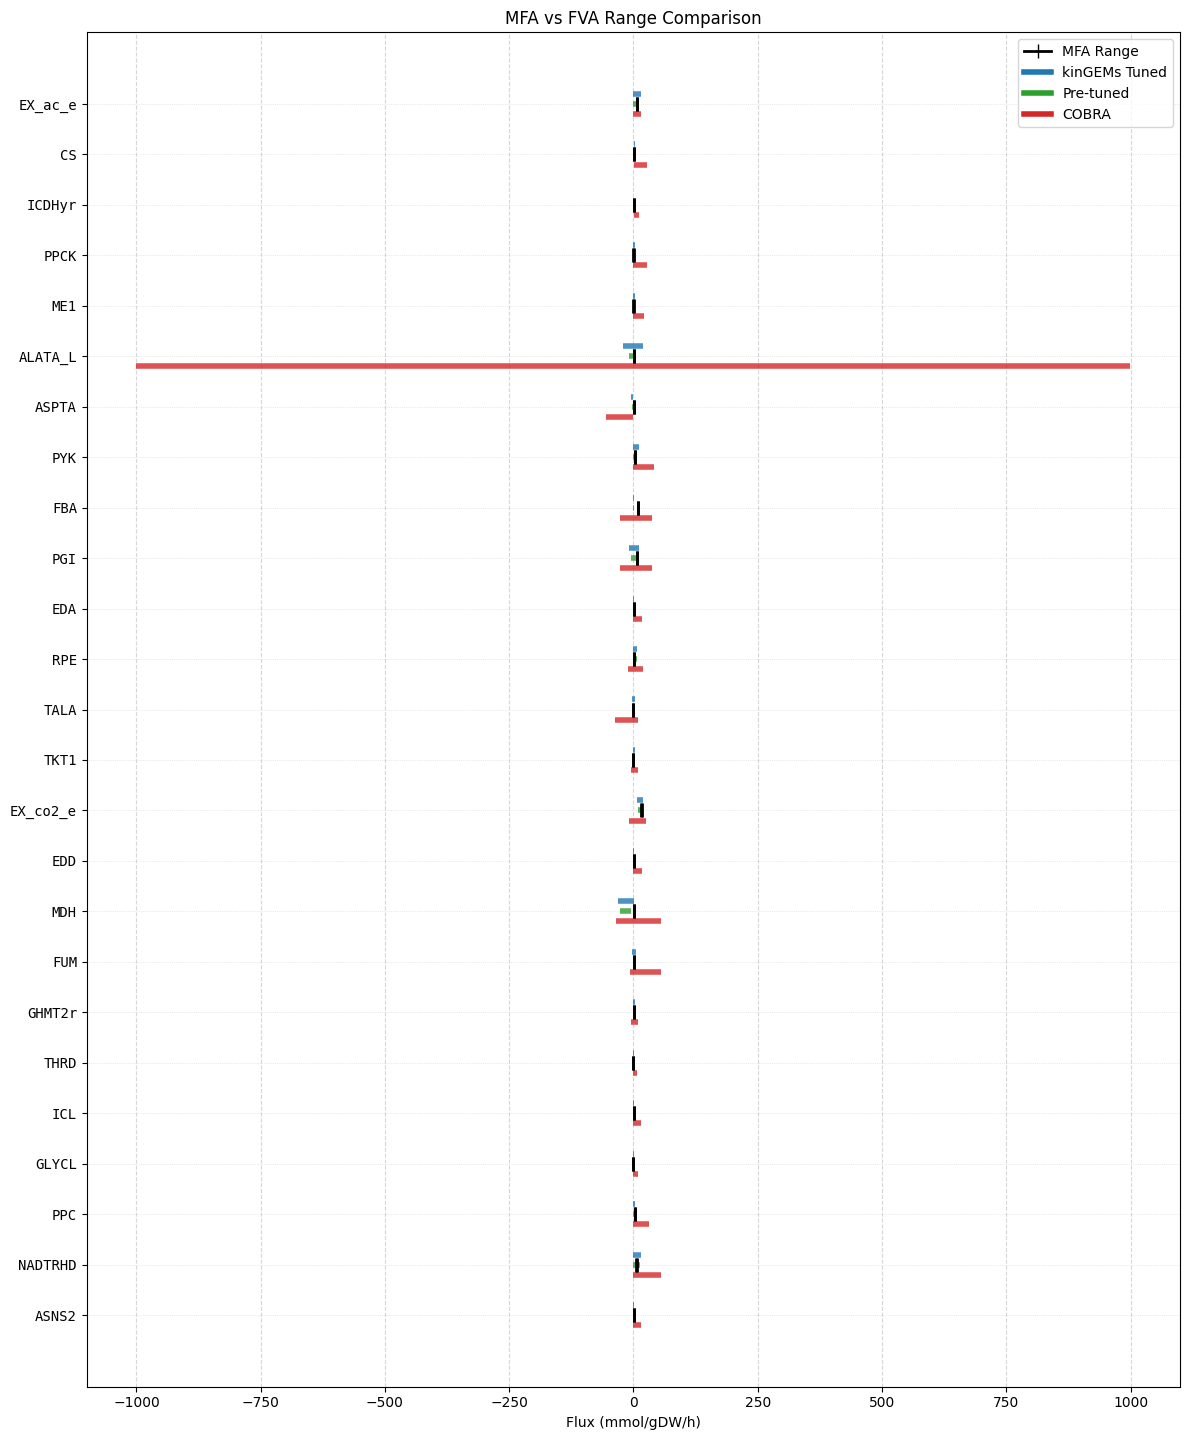

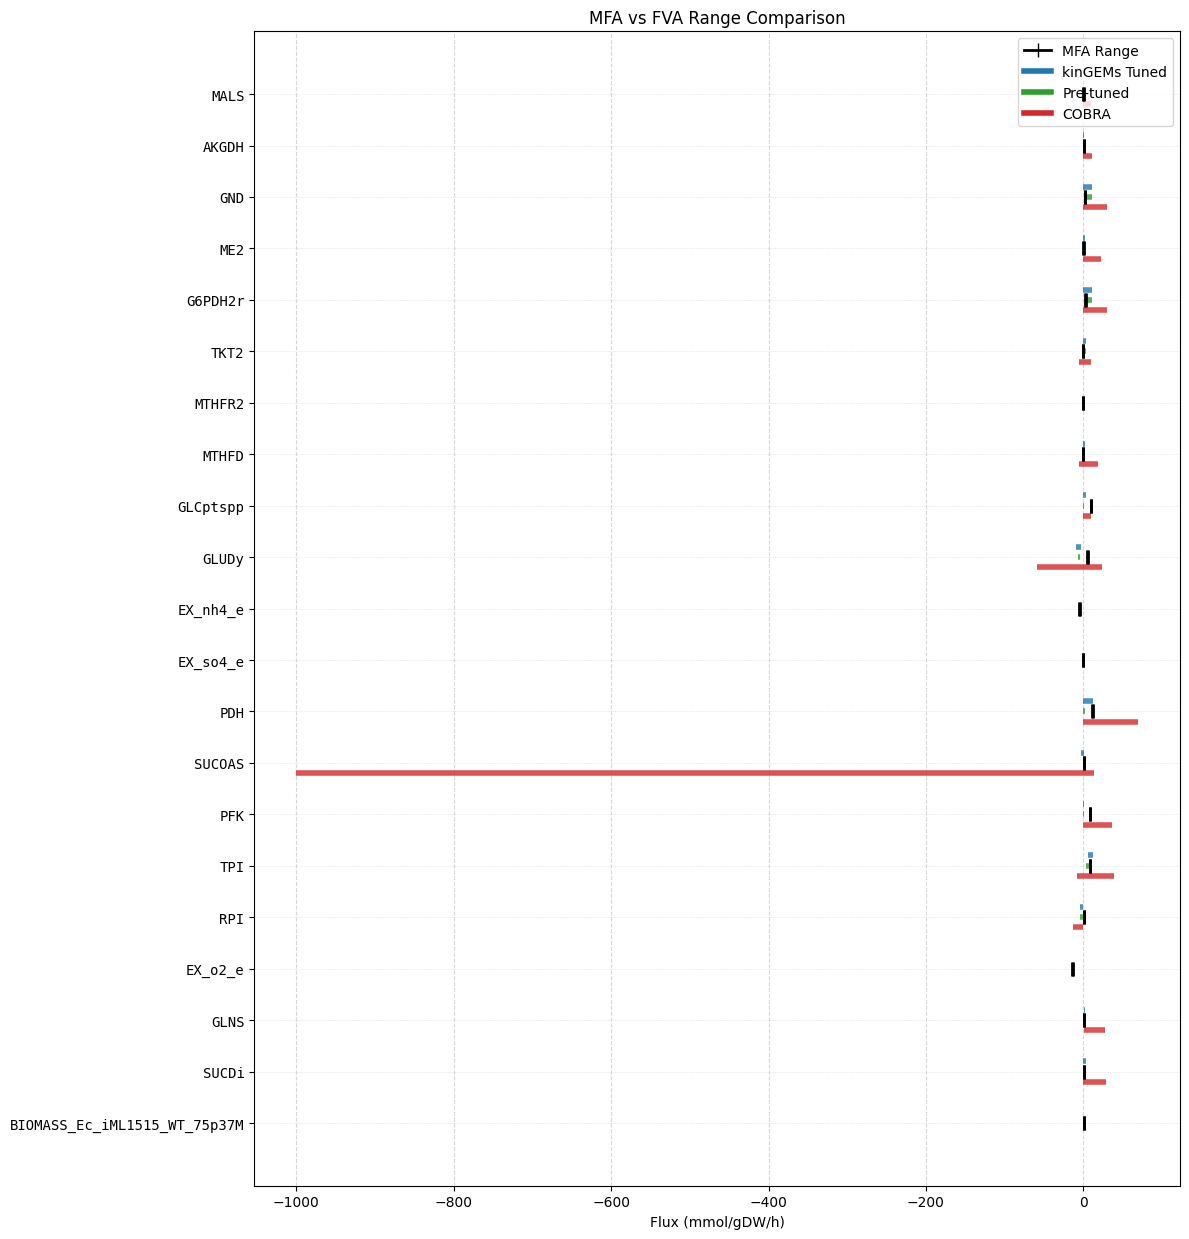

In [23]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva, 'Pre-tuned': df_pre_tuned_fva, 'COBRA': df_cobra_fva})

## Trimming to the rxns with the highest Jaccard Index

In [24]:
# Sort jaccard values in descending order
jaccard_sorted = jaccard_df.sort_values('jaccard', ascending=False)

# top 10 reaction IDs
top_rxn_ids = jaccard_sorted.head(15)['rxn_id'].tolist()

print("Top 10 reactions by Jaccard Index:")
print(jaccard_sorted.head(15))

# Filter dfs to top jaccard reactions
df_tuned_fva_top = df_tuned_fva[df_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_pre_tuned_fva_top = df_pre_tuned_fva[df_pre_tuned_fva['rxn_id'].isin(top_rxn_ids)]
df_cobra_fva_top = df_cobra_fva[df_cobra_fva['rxn_id'].isin(top_rxn_ids)]

Top 10 reactions by Jaccard Index:
      rxn_id   jaccard
4        ME1  0.275943
28       ME2  0.249242
26     AKGDH  0.242373
23   NADTRHD  0.172900
31    MTHFR2  0.132211
2     ICDHyr  0.124799
1         CS  0.117857
0    EX_ac_e  0.116874
3       PPCK  0.115739
22       PPC  0.108136
25      MALS  0.106431
20       ICL  0.098045
37       PDH  0.091629
14  EX_co2_e  0.091287
7        PYK  0.083846


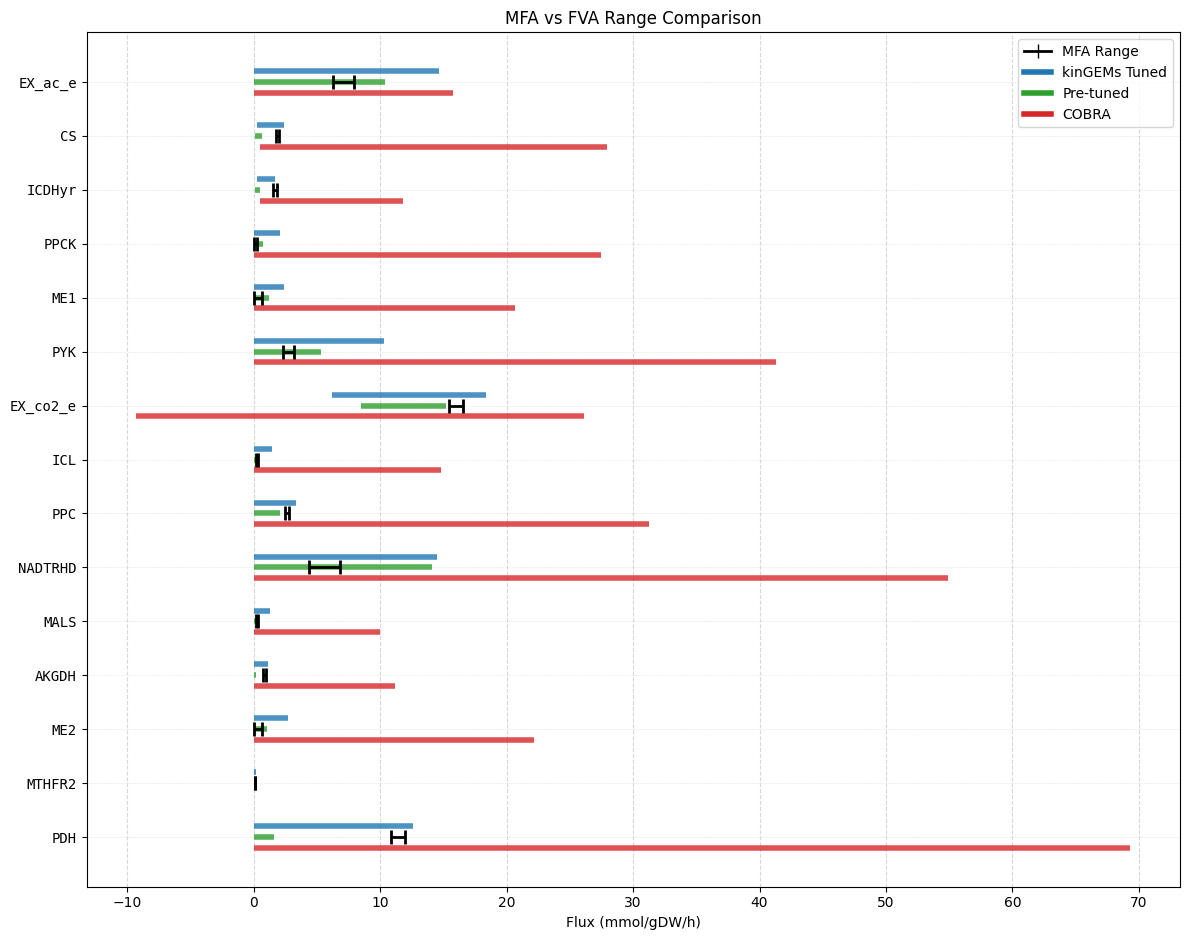

In [25]:
from kinGEMs.fluxomics_validation import plot_fva_mfa_comparison

plot_fva_mfa_comparison({'kinGEMs Tuned': df_tuned_fva_top, 'Pre-tuned': df_pre_tuned_fva_top, 'COBRA': df_cobra_fva_top})

## COBRApy vs kinGEMs tuned

In [28]:
from kinGEMs.fluxomics_validation import create_fva_comparison_dataframe

df_cobra_kingems_fva = create_fva_comparison_dataframe(
    tuned_fva_path,
    cobra_fva_path,
    fva_columns=['Reactions','Min Solutions','Max Solutions'],
    mfa_columns=['Reactions','Min Solutions','Max Solutions']
)

Loaded 2712 FVA flux results
Loaded 2712 MFA flux measurements
Merged dataframe has 2712 rows
Matched reactions: 2712
Unmatched reactions: 0



In [29]:
from kinGEMs.fluxomics_validation import (calculate_consistency_score, 
                                        calculate_range_precision_ratio, 
                                        calculate_normalized_euclidean_dist, 
                                        calculate_jaccard_index)

consistency_score = calculate_consistency_score(df_cobra_kingems_fva)
range_precision_ratio = calculate_range_precision_ratio(df_cobra_kingems_fva)
normalized_euclidean_dist = calculate_normalized_euclidean_dist(df_cobra_kingems_fva)
jaccard_index = calculate_jaccard_index(df_cobra_kingems_fva)


--- Consistency Score Analysis ---
Evaluated 2712 reactions
Consistent reactions: 2624
Consistency Score: 0.9676

--- Range Precision Analysis ---
Evaluated 2712 reactions
Median FVA width: 0.1852
Median MFA width: 0.5239
Median Precision Ratio: 0.0710

--- Euclidean Distance Analysis ---
Evaluated 2712 reactions
Reactions with mean outside FVA range: 1487
Sum of Squared Distances (SSD): 11583929.8980

--- Jaccard Index Analysis ---
Evaluated 2712 reactions
Perfect overlaps (J=1.0): 5
Zero overlaps (J=0.0): 1086
Mean Jaccard Index: 0.1146
